# Q10.
```{admonition}
:class: note
This question relates to the `College` data set.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pygam import f as gmf, s as gms, LinearGAM

In [3]:
from sklearn.model_selection import cross_val_score, KFold, GridSearchCV, train_test_split
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import mean_squared_error,r2_score,make_scorer
from sklearn.linear_model import LinearRegression

In [4]:
rng = np.random.default_rng(1729)

def gamfit(df:pd.DataFrame,cols:list,target:str) -> LinearGAM:
    y = df[target]
    X = df[cols]
    categorical_cols = [col for col in X.select_dtypes(include=['category','bool'])]
    terms = [gmf(i) if col in categorical_cols else gms(i) for i,col in enumerate(cols)]
    gam = LinearGAM(np.sum(terms))
    param_grid = {'lam':np.exp(rng.random(size=(100,len(cols))))}
    return gam.gridsearch(X,y,**param_grid)

def gamplot(gam:LinearGAM,df:pd.DataFrame,cols:list,target:str):
    fig, axs = plt.subplots(1, len(cols),figsize=(20,4))
    for i, ax in enumerate(axs):
        XX = gam.generate_X_grid(term=i)
        ax.plot(XX[:, i], gam.partial_dependence(term=i, X=XX))
        ax.plot(
            XX[:, i], gam.partial_dependence(term=i, X=XX, width=0.95)[1], c="r", ls="--"
        )
        ax.set_title(cols[i])

In [ ]:
college = pd.read_csv('../../../ALL CSV FILES - 2nd Edition/College.csv',index_col=0)

In [6]:
college.sample(3)

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
Campbellsville College,Yes,848,587,298,25,55,935,184,6060,3070,600,1300,62,66,17.7,13,5391,49
Lewis and Clark College,Yes,2774,2092,482,35,64,1763,59,15800,4790,450,950,97,98,12.3,21,12999,69
Elizabethtown College,Yes,2417,1843,426,36,70,1476,299,14190,4400,500,750,65,68,12.8,25,9815,81


## (a)
```{admonition}
:class: note
Split the data into a training set and a test set. Using out-of-state tuition as the response and the other variables as the predictors, perform forward stepwise selection on the training set in order to identify a satisfactory model that uses just a subset of the predictors.

In [7]:
college['Private'] = college['Private']=='Yes'
college_train, college_test = train_test_split(college)

In [8]:
X_train, y_train = college.drop(columns='Outstate'),college['Outstate']
forward_selection = SequentialFeatureSelector(LinearRegression(),cv=10,n_features_to_select='auto', tol=0.001)
forward_selection.fit(X_train,y_train)

,estimator,LinearRegression()
,n_features_to_select,'auto'
,tol,0.001
,direction,'forward'
,scoring,None
,cv,10
,n_jobs,None
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


In [9]:
forward_features = X_train.columns[forward_selection.get_support()]
forward_features

Index(['Private', 'Room.Board', 'Personal', 'PhD', 'perc.alumni', 'Expend',
       'Grad.Rate'],
      dtype='str')

## (b)
```{admonition}
:class: note
Fit a GAM on the training data, using out-of-state tuition as the response and the features selected in the previous step as the predictors. Plot the results, and explain your findings.

In [10]:
gam_model = gamfit(college_train, forward_features,'Outstate')

100% (100 of 100) |######################| Elapsed Time: 0:00:03 Time:  0:00:030000


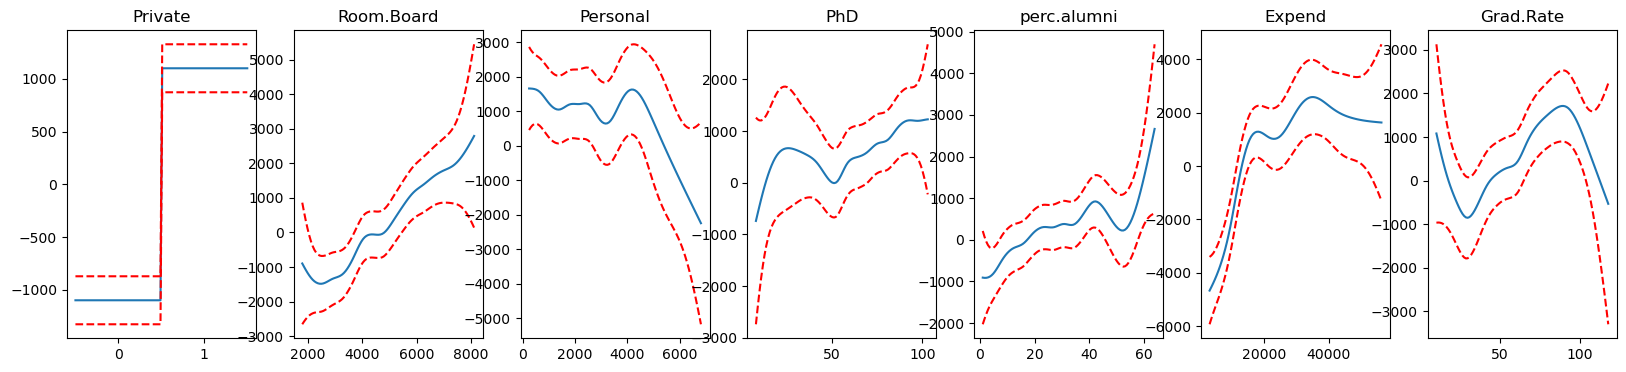

In [11]:
gamplot(gam_model,college_train, forward_features,'Outstate')

## (c)
```{admonition}
:class: note
Evaluate the model obtained on the test set, and explain the results obtained.

Holdout RMSE: 1912.0291727567335
Holdout R2: 0.7121700683915886


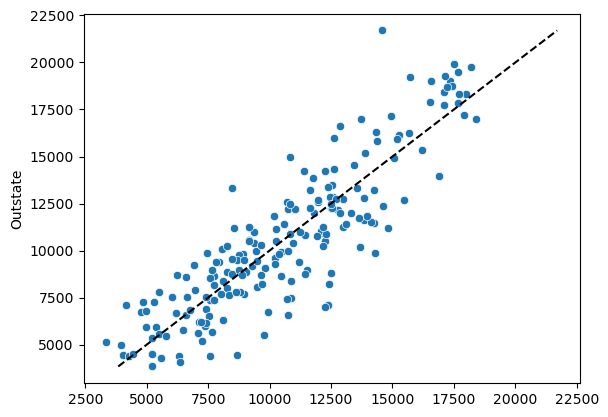

In [12]:
gam_preds = gam_model.predict(college_test[forward_features])
test_mse = mean_squared_error(gam_preds,college_test['Outstate'])
test_r2 = r2_score(gam_preds,college_test['Outstate'])
print(f'Holdout RMSE: {np.sqrt(test_mse)}')
print(f'Holdout R2: {test_r2}')
sns.scatterplot(x=gam_preds,y=college_test['Outstate']);
plt.plot([college_test['Outstate'].min(),college_test['Outstate'].max()],[college_test['Outstate'].min(),college_test['Outstate'].max()],'k--')
plt.show()

## (d)
```{admonition}
:class: note
For which variables, if any, is there evidence of a non-linear relationship with the response?

In [14]:
import warnings
gam_model.summary()

warnings.filterwarnings('ignore')

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     49.4803
Link Function:                     IdentityLink Log Likelihood:                                 -5171.4052
Number of Samples:                          582 AIC:                                             10443.771
                                                AICc:                                            10453.568
                                                GCV:                                          3925065.1202
                                                Scale:                                           1824.6551
                                                Pseudo R-Squared:                                   0.8134
Feature Function                  Lam